In [7]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import os
#from "..\utils" import *

In [8]:
df = xr.open_dataset("..\\CTSM_data\\run_1\\merged_files\\TVC_1995-2014.nc", engine="netcdf4")
var_soilm = df["H2OSOI"]
var_soilm

C:\Users\madel\AppData\Local\Temp\ipykernel_28716\1052927314.py:1: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  df = xr.open_dataset("..\\CTSM_data\\run_1\\merged_files\\TVC_1995-2014.nc", engine="netcdf4")


<xarray.DataArray 'H2OSOI' (time: 7300, levsoi: 20, lndgrid: 1)> Size: 584kB
[146000 values with dtype=float32]
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * levsoi   (levsoi) float32 80B 0.01 0.04 0.09 0.16 ... 5.06 5.95 6.94 8.03
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      volumetric soil water (natural vegetated and crop landuni...
    units:          mm3/mm3
    cell_methods:   time: mean
    landunit_mask:  veg

In [9]:
df

<xarray.Dataset> Size: 14MB
Dimensions:                        (time: 7300, hist_interval: 2, lndgrid: 1,
                                    levgrnd: 25, levlak: 10, levsoi: 20,
                                    cft: 64, glc_nec: 10, ltype: 9, natpft: 15,
                                    nvegwcs: 4, levdcmp: 1)
Coordinates:
  * time                           (time) object 58kB 1995-01-01 00:00:00 ......
  * levgrnd                        (levgrnd) float32 100B 0.01 0.04 ... 42.0
  * levlak                         (levlak) float32 40B 0.05 0.6 ... 34.33 44.78
  * levsoi                         (levsoi) float32 80B 0.01 0.04 ... 6.94 8.03
  * levdcmp                        (levdcmp) float32 4B 1.0
Dimensions without coordinates: hist_interval, lndgrid, cft, glc_nec, ltype,
                                natpft, nvegwcs
Data variables: (12/259)
    mcdate                         (time) int32 29kB ...
    mcsec                          (time) int32 29kB ...
    mdcur                          (time) int32 29kB ...
    mscur                          (time) int32 29kB ...
    nstep                          (time) int32 29kB ...
    time_bounds                    (time, hist_interval) object 117kB ...
    ...                             ...
    SOILLIQ                        (time, levsoi, lndgrid) float32 584kB ...
    PCT_LANDUNIT                   (time, ltype, lndgrid) float32 263kB ...
    PCT_NAT_PFT                    (time, natpft, lndgrid) float32 438kB ...
    VEGWP                          (time, nvegwcs, lndgrid) float32 117kB ...
    VEGWPLN                        (time, nvegwcs, lndgrid) float32 117kB ...
    VEGWPPD                        (time, nvegwcs, lndgrid) float32 117kB ...
Attributes: (12/100)
    title:                                CLM History file information
    comment:                              NOTE: None of the variables are wei...
    Conventions:                          CF-1.0
    history:                              Thu Mar 26 11:29:19 2026: ncrcat TV...
    source:                               Community Terrestrial Systems Model
    hostname:                             trillium
    ...                                   ...
    cft_tropical_corn:                    61
    cft_irrigated_tropical_corn:          62
    cft_tropical_soybean:                 63
    cft_irrigated_tropical_soybean:       64
    time_period_freq:                     day_1
    NCO:                                  netCDF Operators version 5.2.1 (Hom...

In [10]:
def obs_data_parse(file):
    obs = pd.read_csv(
    f"{file}",   # just change the extension
    comment="#",
    sep=r"\s+|,|\t",
    parse_dates=["Timestamp"],
    engine="python"
    )
    obs.rename(columns={"Timestamp": "time", "Value": "obs_m"}, inplace=True)
    return obs

In [11]:
# Input ypur path to all observational values
# Makes a simple list for now but could definitely be a dictionary later
directory_path = "TVC_obs/soil_moisture"
observe = {}

for filename in os.listdir(directory_path):
    # Join the directory path and the filename to get the full file path
    full_path = os.path.join(directory_path, filename)
    # Check if it is a file (not a directory)
    if os.path.isfile(full_path):
        df = obs_data_parse(full_path)
        observe.update({f"{filename}":df})

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'TVC_obs/soil_moisture'

In [12]:
for x in observe:
  print(observe[x]) 

C:\Users\madel\AppData\Local\Temp\ipykernel_28716\1019604037.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


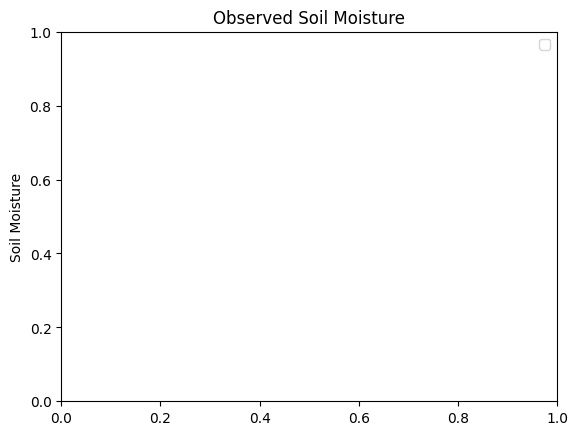

In [13]:
for data in observe:  
    plt.plot(observe[data]["time"], observe[data]["obs_m"], label=f"{data}")
plt.ylabel("Soil Moisture")
plt.title("Observed Soil Moisture")
plt.legend()
plt.show()

In [14]:
var_soilm

<xarray.DataArray 'H2OSOI' (time: 7300, levsoi: 20, lndgrid: 1)> Size: 584kB
[146000 values with dtype=float32]
Coordinates:
  * time     (time) object 58kB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * levsoi   (levsoi) float32 80B 0.01 0.04 0.09 0.16 ... 5.06 5.95 6.94 8.03
Dimensions without coordinates: lndgrid
Attributes:
    long_name:      volumetric soil water (natural vegetated and crop landuni...
    units:          mm3/mm3
    cell_methods:   time: mean
    landunit_mask:  veg

Units are actually the same and the initial graph looks fine so no conversion or cleaning needed, but I'm just gonna stick with one file cause its infinitely more complete.

In [ ]:
for x in observe:
    print(x)

TVC_soil_moist_15.txt
TVC_soil_moist_8.txt


In [ ]:
obs_8 = observe["TVC_soil_moist_8.txt"]
obs_15 = observe["TVC_soil_moist_15.txt"]

C:\Users\madel\AppData\Local\Temp\ipykernel_13108\337000126.py:1: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.open_dataset("HC_1995-2014.nc", engine="netcdf4")


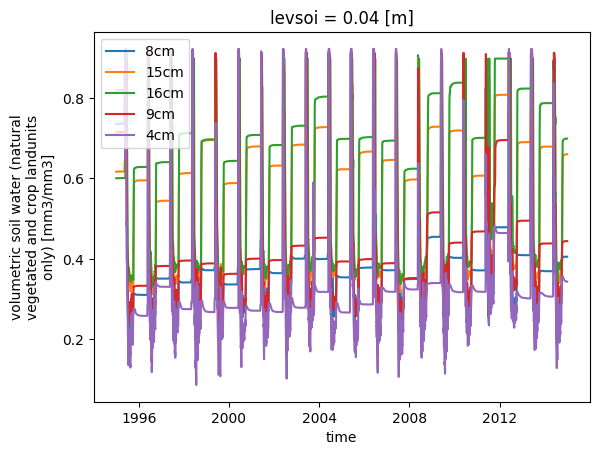

In [ ]:
ds = xr.open_dataset("HC_1995-2014.nc", engine="netcdf4")

def interpolate_to_depth(ds, var, target_depth, depth_dim="levsoi"):
    sm = ds[var].squeeze()
    depths = ds[depth_dim].values.flatten()
    
    # Convert CFTime to pandas datetime here, once
    cf_times = ds.indexes['time']
    time = pd.to_datetime([f"{t.year}-{t.month:02d}-{t.day:02d}" 
                           for t in cf_times])
    
    # Interpolate
    idx = int(np.searchsorted(depths, target_depth, side="right") - 1)
    idx = int(np.clip(idx, 0, len(depths) - 2))
    z0, z1 = depths[idx], depths[idx + 1]
    w = (target_depth - z0) / (z1 - z0)
    sm_interp = ((1 - w) * sm.values[:, idx] + w * sm.values[:, idx + 1]).flatten()
    
    return xr.DataArray(
        sm_interp,
        coords={"time": time},
        dims=["time"],
        attrs={"units": ds[var].attrs.get("units", ""), 
               "long_name": f"{var} interpolated at {target_depth}m"},
    )


sim8 = interpolate_to_depth(ds, "H2OSOI", target_depth=0.08)
sim15 = interpolate_to_depth(ds, "H2OSOI", target_depth=0.15)
#plot with regular CTSM data for comparison


# Convert var_soilm time coordinate to pandas datetime
var_soilm_converted = var_soilm.assign_coords(
    time=pd.to_datetime([f"{t.year}-{t.month:02d}-{t.day:02d}" 
                         for t in var_soilm.indexes['time']])
)

# Now plot all together
sim8.plot(label="8cm")
sim15.plot(label="15cm")
var_soilm_converted.isel(levsoi=3).plot(label="16cm")
var_soilm_converted.isel(levsoi=2).plot(label="9cm")
var_soilm_converted.isel(levsoi=1).plot(label="4cm")
plt.legend()
plt.show()  # Note: needs () to actually call it


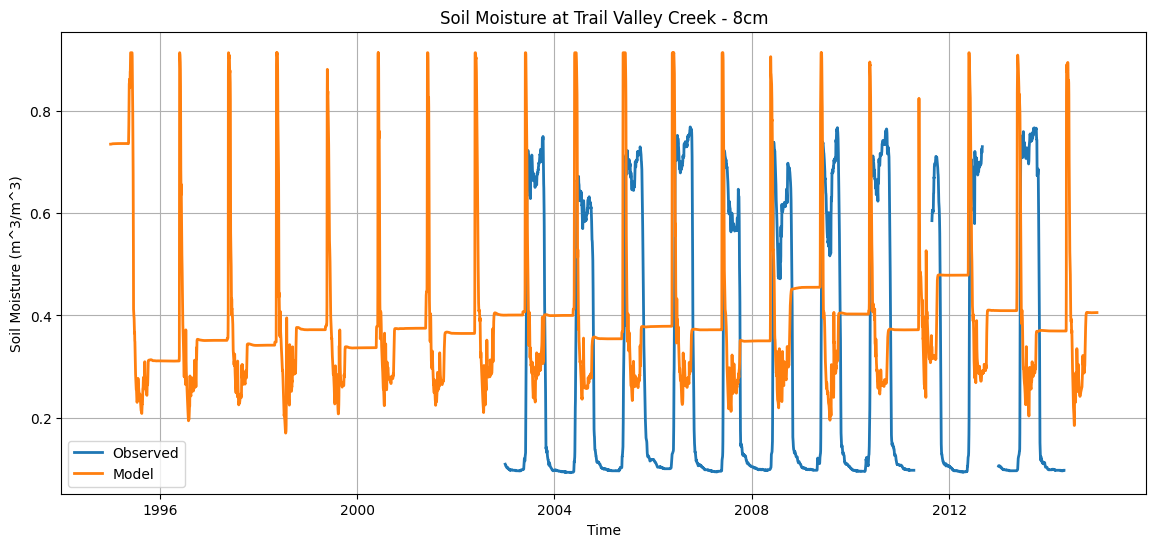

In [ ]:
# Convert pandas → xarray
obs = obs_8.set_index("time").to_xarray()

# Resample observational data to daily frequency
obs_daily = obs.resample(time="1D").mean()


plt.figure(figsize=(14,6))

# Observed (daily)
plt.plot(
    obs_daily["time"].values,
    obs_daily["obs_m"].values,
    label="Observed",
    linewidth=2
)

# Simulated
plt.plot(
    sim8["time"].values,
    sim8.values,
    label="Model",
    linewidth=2
)

plt.xlabel("Time")
plt.ylabel("Soil Moisture (m^3/m^3)")
plt.title("Soil Moisture at Trail Valley Creek - 8cm")
plt.grid(True)
plt.legend()
plt.savefig("0_final_images/TVC_soil_moisture_8.png")
plt.show()

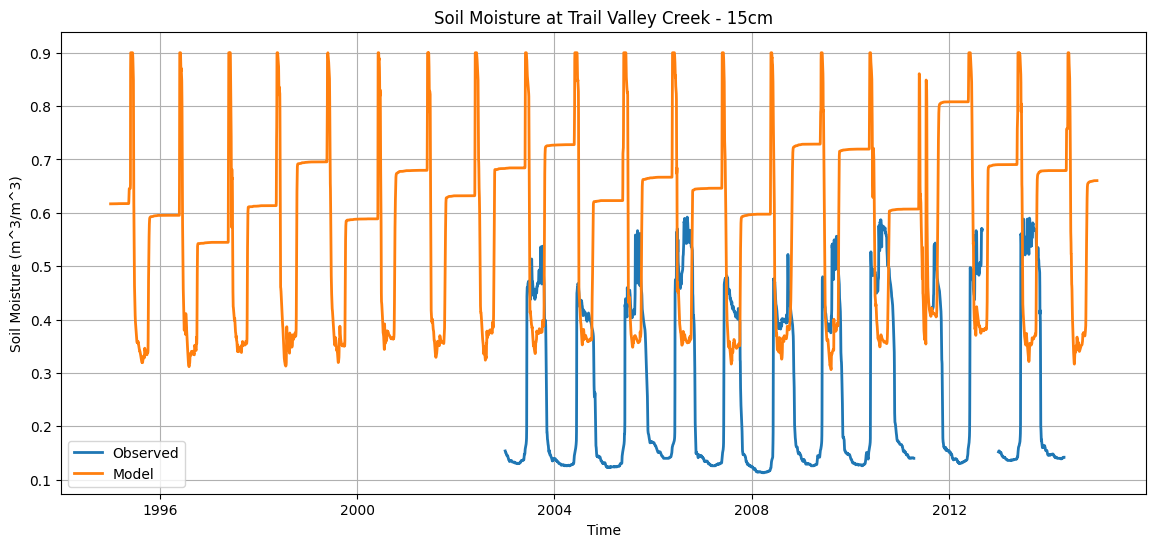

In [ ]:
# Convert pandas → xarray
obs = obs_15.set_index("time").to_xarray()

# Resample observational data to daily frequency
obs_daily = obs.resample(time="1D").mean()


plt.figure(figsize=(14,6))

# Observed (daily)
plt.plot(
    obs_daily["time"].values,
    obs_daily["obs_m"].values,
    label="Observed",
    linewidth=2
)

# Simulated
plt.plot(
    sim15["time"].values,
    sim15.values,
    label="Model",
    linewidth=2
)

plt.xlabel("Time")
plt.ylabel("Soil Moisture (m^3/m^3)")
plt.xlim(pd.Timestamp('2002-06-01 07:30:00+00:00'), pd.Timestamp('2002-07-01 07:30:00+00:00'))
plt.title("Soil Moisture at Trail Valley Creek - 15cm")
plt.grid(True)
plt.legend()
plt.savefig("0_final_images/TVC_soil_moisture_15.png")
plt.show()